# **Day 56: Machine Learning for Time-Series Forecasting**
*Module 9 - Probabilistic ML, Time Series and Semi-Supervised Learning*

Gradient boosting and Random Forests win many forecasting competitions (e.g. the M5 retail competition) when the problem is framed as **supervised learning on engineered features**. Today we build a complete, leakage-free ML forecasting pipeline for daily river discharge driven by rainfall.

> ML models can forecast time series once the series is turned into a table of lagged values and calendar features. The golden rule is to never use the future to predict the past, so validation must move forward in time.
>
> *Example:* To predict next week's reservoir level, the features are the last four weeks' levels and rainfall, never next week's rainfall.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
rng = np.random.default_rng(56)

## **1. Simulated Daily Rainfall-Runoff Data**
Rainfall (monsoon-seasonal, intermittent) feeds a catchment that drains slowly: discharge responds to rain of the last few days and to **baseflow** from weeks of accumulated wetness.

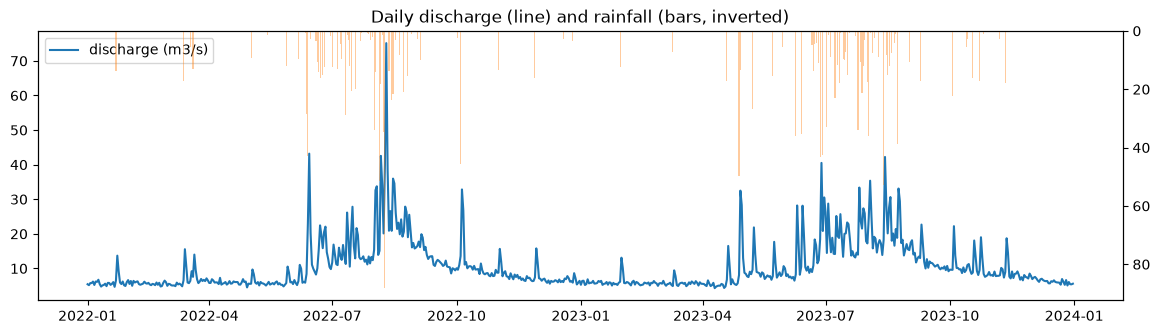

In [2]:
dates = pd.date_range("2015-01-01", "2024-12-31", freq="D"); n = len(dates)
doy = dates.dayofyear.values
p_rain = 0.05 + 0.6 * np.exp(-((doy - 200) / 40) ** 2)                       # monsoon peak in July-August
rain = np.where(rng.random(n) < p_rain, rng.gamma(0.8, 18, n), 0.0)
storage, q = 0.0, np.zeros(n)
for i in range(n):
    storage = 0.97 * storage + 0.6 * rain[i]                                 # slow store
    q[i] = 5 + 0.08 * storage + 0.5 * (rain[i - 1] if i else 0) + 0.25 * (rain[i - 2] if i > 1 else 0)
q = q * rng.lognormal(0, 0.08, n)
df = pd.DataFrame({"rain": rain, "discharge": q}, index=dates)
fig, ax = plt.subplots(figsize=(14, 3.5)); ax.plot(df.discharge["2022":"2023"], label="discharge (m3/s)")
ax2 = ax.twinx(); ax2.bar(df["2022":"2023"].index, df.rain["2022":"2023"], color="C1", alpha=0.4); ax2.invert_yaxis()
ax.legend(loc="upper left"); ax.set_title("Daily discharge (line) and rainfall (bars, inverted)"); plt.show()

## **2. Feature Engineering for Forecasting**
Goal: forecast **tomorrow's discharge** (h = 1) using information available **today**.

| Feature | Example | Rule |
|---|---|---|
| Lags of the target | $q_{t}, q_{t-1}, q_{t-7}$ | only past values |
| Rolling statistics | mean of $q$ over the last 7 / 30 days | windows must end at $t$ |
| Exogenous drivers | rainfall today and in previous days; **forecast** rain for tomorrow if it will be available | use only what is known at prediction time |
| Calendar | day-of-year (sin/cos), month | always known |

In [3]:
def make_features(d, horizon=1):
    X = pd.DataFrame(index=d.index)
    for lag in [0, 1, 2, 3, 7, 14, 30]:
        X[f"q_lag{lag}"] = d.discharge.shift(lag)
    for w in [3, 7, 30, 90]:
        X[f"q_mean{w}"] = d.discharge.rolling(w).mean()
        X[f"rain_sum{w}"] = d.rain.rolling(w).sum()
    for lag in [0, 1, 2]:
        X[f"rain_lag{lag}"] = d.rain.shift(lag)
    X["doy_sin"] = np.sin(2 * np.pi * d.index.dayofyear / 365.25); X["doy_cos"] = np.cos(2 * np.pi * d.index.dayofyear / 365.25)
    y = d.discharge.shift(-horizon)                                             # the target is in the FUTURE
    data = X.assign(target=y).dropna()
    return data.drop(columns="target"), data.target

X, y = make_features(df, horizon=1)
split = X.index < "2023-01-01"
X_tr, X_te, y_tr, y_te = X[split], X[~split], y[split], y[~split]
print(X.shape, "| train until 2022, test 2023-2024")

(3563, 20) | train until 2022, test 2023-2024


## **3. Models and Baselines**

In [4]:
preds = {"persistence (q_t)": X_te.q_lag0, "seasonal mean": X_te.index.dayofyear.map(df[:"2022"].groupby(df[:"2022"].index.dayofyear).discharge.mean())}
models = {"Ridge": RidgeCV(alphas=np.logspace(-3, 3, 20)),
          "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=500, learning_rate=0.05, random_state=0),
          "LightGBM": lgb.LGBMRegressor(n_estimators=600, learning_rate=0.03, num_leaves=31, subsample=0.8, subsample_freq=1, colsample_bytree=0.8, verbose=-1, random_state=0)}
for name, m in models.items():
    preds[name] = pd.Series(m.fit(X_tr, y_tr).predict(X_te), index=X_te.index)

def nse(obs, sim):
    """Nash-Sutcliffe efficiency, the standard hydrology skill score (1 = perfect, 0 = as good as the mean)."""
    return 1 - np.sum((obs - sim) ** 2) / np.sum((obs - obs.mean()) ** 2)
pd.DataFrame({k: {"MAE": mean_absolute_error(y_te, v), "NSE": nse(y_te.values, np.asarray(v, float))} for k, v in preds.items()}).T.round(3)

,MAE,NSE
persistence (q_t),2.773,0.553
seasonal mean,3.121,0.494
Ridge,0.849,0.974
HistGradientBoosting,0.978,0.962
LightGBM,0.921,0.967


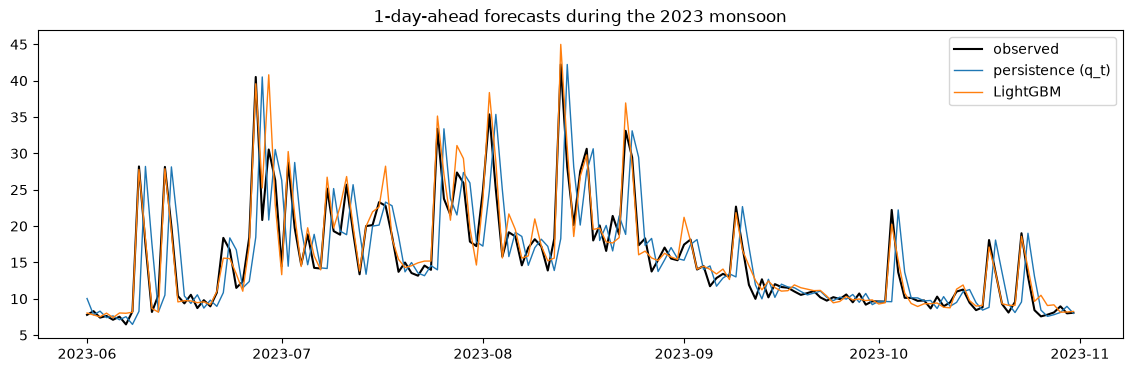

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_te["2023-06":"2023-10"], "k", lw=1.5, label="observed")
for k in ["persistence (q_t)", "LightGBM"]:
    ax.plot(pd.Series(preds[k], index=X_te.index)["2023-06":"2023-10"], lw=1, label=k)
ax.legend(); ax.set_title("1-day-ahead forecasts during the 2023 monsoon"); plt.show()

## **4. Leakage Traps in Time Series**
1. **Random train/test split**: the model sees the day after a test day during training (Day 40).
2. **Centred rolling windows** (`rolling(7, center=True)`) use future values.
3. **Scaling/normalising with statistics of the whole series**.
4. **Target shifted the wrong way**: a feature that is actually $y_{t+1}$.
5. **Exogenous data not available at forecast time** (e.g. using **observed** tomorrow's rainfall in an operational forecast).

In [6]:
X_leak = X.copy(); X_leak["q_centred_mean3"] = df.discharge.rolling(3, center=True).mean().reindex(X.index)   # uses q(t+1): the target!
m_leak = lgb.LGBMRegressor(n_estimators=600, learning_rate=0.03, verbose=-1, random_state=0).fit(X_leak[split], y_tr)
print(f"with a centred 3-day rolling mean (contains tomorrow's value): NSE {nse(y_te.values, m_leak.predict(X_leak[~split])):.3f}  <- too good to be true")
print(f"honest model                                                  : NSE {nse(y_te.values, preds['LightGBM'].values):.3f}")

with a centred 3-day rolling mean (contains tomorrow's value): NSE 0.979  <- too good to be true
honest model                                                  : NSE 0.967


## **5. Time-Series Cross-Validation for Tuning**

In [7]:
tscv = TimeSeriesSplit(n_splits=5, gap=30, test_size=365)
for lr_ in [0.01, 0.03, 0.1]:
    scores = []
    for tr, va in tscv.split(X_tr):
        m = lgb.LGBMRegressor(n_estimators=600, learning_rate=lr_, verbose=-1, random_state=0).fit(X_tr.iloc[tr], y_tr.iloc[tr])
        scores.append(nse(y_tr.iloc[va].values, m.predict(X_tr.iloc[va])))
    print(f"learning_rate {lr_}: CV NSE {np.mean(scores):.3f} +/- {np.std(scores):.3f}")

learning_rate 0.01: CV NSE 0.960 +/- 0.010


learning_rate 0.03: CV NSE 0.960 +/- 0.009


learning_rate 0.1: CV NSE 0.958 +/- 0.008


## **6. Multi-Step Forecasting: Recursive vs Direct**
To forecast 1..H days ahead:
- **Recursive**: one 1-step model; feed its own predictions back as lags. Errors accumulate.
- **Direct**: one model per horizon $h$ (target shifted by $h$). No feedback, more models.

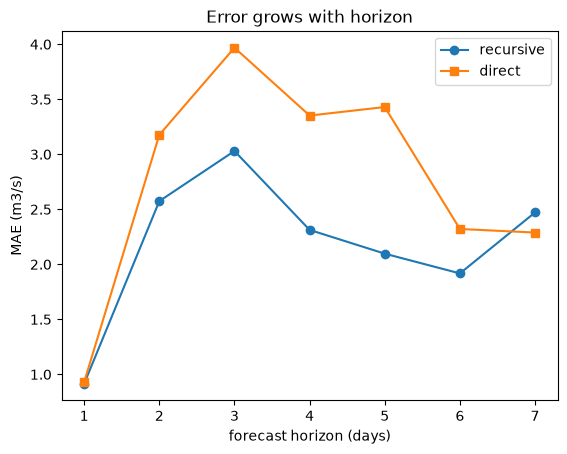

In [8]:
H = 7
direct_models = {}
for h in range(1, H + 1):
    Xh, yh = make_features(df, horizon=h)
    direct_models[h] = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, verbose=-1, random_state=0).fit(Xh[Xh.index < "2023-01-01"], yh[Xh.index < "2023-01-01"])
one_step = models["LightGBM"]

def recursive_forecast(history, start, H):
    hist = history.loc[:start].iloc[-120:].copy(); out = []          # 120 days is enough for the longest (90-day) window
    for h in range(H):
        Xrow = make_features(hist, horizon=0)[0].iloc[[-1]]           # features on the last known day
        yhat = one_step.predict(Xrow)[0]; out.append(yhat)
        nxt = hist.index[-1] + pd.Timedelta(days=1)
        hist = pd.concat([hist, pd.DataFrame({"rain": [0.0], "discharge": [yhat]}, index=[nxt])])   # feed the prediction back; future rain unknown -> 0
    return np.array(out)

origins = pd.date_range("2023-02-01", "2024-11-01", freq="15D")
err_rec, err_dir = np.zeros(H), np.zeros(H)
for o in origins:
    truth = df.discharge.loc[o + pd.Timedelta(days=1): o + pd.Timedelta(days=H)].values
    err_rec += np.abs(recursive_forecast(df, o, H) - truth)
    Xo = make_features(df.loc[:o].iloc[-120:], horizon=0)[0].iloc[[-1]]
    err_dir += np.abs(np.array([direct_models[h].predict(Xo)[0] for h in range(1, H + 1)]) - truth)
plt.plot(range(1, H + 1), err_rec / len(origins), "o-", label="recursive"); plt.plot(range(1, H + 1), err_dir / len(origins), "s-", label="direct")
plt.xlabel("forecast horizon (days)"); plt.ylabel("MAE (m3/s)"); plt.legend(); plt.title("Error grows with horizon"); plt.show()

(Both strategies here assume no future rainfall information; operational systems feed **weather forecasts** as exogenous inputs, which matters most for floods.)

## **7. Probabilistic Forecasts with Quantile Boosting**
Flood warning needs **ranges**, not just a mean. Train one model per quantile (Day 26) and check calibration: about 80% of observations should fall inside the 10-90% band.

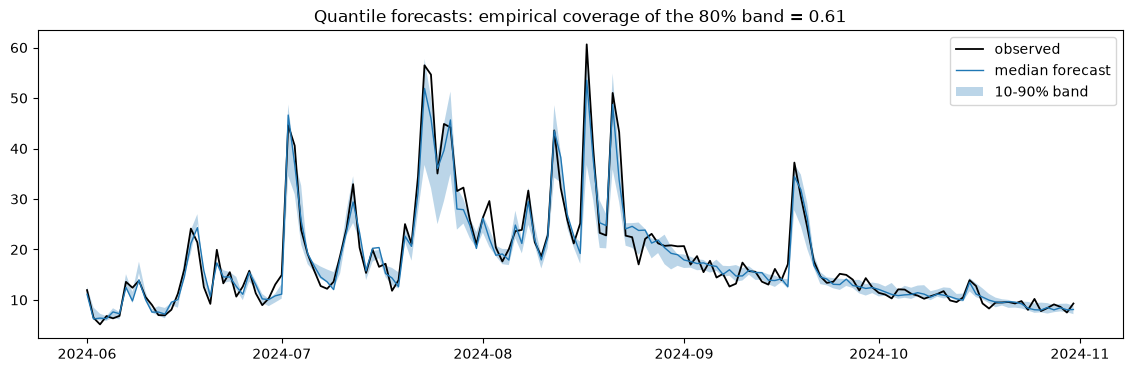

In [9]:
qmods = {q: lgb.LGBMRegressor(objective="quantile", alpha=q, n_estimators=600, learning_rate=0.03, verbose=-1, random_state=0).fit(X_tr, y_tr) for q in [0.1, 0.5, 0.9]}
Q = {q: pd.Series(m.predict(X_te), index=X_te.index) for q, m in qmods.items()}
cover = np.mean((y_te >= Q[0.1]) & (y_te <= Q[0.9]))
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_te["2024-06":"2024-10"], "k", lw=1.3, label="observed"); ax.plot(Q[0.5]["2024-06":"2024-10"], "C0", lw=1, label="median forecast")
ax.fill_between(Q[0.1]["2024-06":"2024-10"].index, Q[0.1]["2024-06":"2024-10"], Q[0.9]["2024-06":"2024-10"], alpha=0.3, label="10-90% band")
ax.legend(); ax.set_title(f"Quantile forecasts: empirical coverage of the 80% band = {cover:.2f}"); plt.show()

# **Part 2: Going Deeper**

### Trees cannot extrapolate trends
Tree models predict within the range of training targets. For trending series: **difference** the target (predict the change $y_{t+1} - y_t$), **detrend** first, or combine a linear trend model with trees on the residuals.

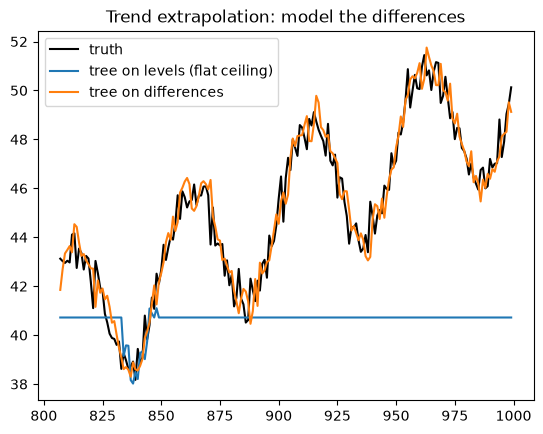

In [10]:
tt = np.arange(1000); trend_series = 0.05 * tt + 3 * np.sin(2 * np.pi * tt / 50) + rng.normal(0, 0.5, 1000)
s = pd.Series(trend_series)
Xs = pd.DataFrame({f"lag{k}": s.shift(k) for k in range(1, 8)}).assign(y=s, dy=s.diff()).dropna()
tr_, te_ = Xs.iloc[:800], Xs.iloc[800:]
lag_cols = [f"lag{k}" for k in range(1, 8)]
level = HistGradientBoostingRegressor(random_state=0).fit(tr_[lag_cols], tr_.y).predict(te_[lag_cols])
diffm = HistGradientBoostingRegressor(random_state=0).fit(tr_[lag_cols].sub(tr_.lag1, axis=0), tr_.y - tr_.lag1)
diff_pred = te_.lag1 + diffm.predict(te_[lag_cols].sub(te_.lag1, axis=0))
plt.plot(te_.index, te_.y, "k", label="truth"); plt.plot(te_.index, level, label="tree on levels (flat ceiling)"); plt.plot(te_.index, diff_pred, label="tree on differences")
plt.legend(); plt.title("Trend extrapolation: model the differences"); plt.show()

### Global models
Instead of one model per series (per river gauge, per store, per pixel), train **one global model** on all series together with series-level features (catchment area, land cover). Global models share information and usually outperform local ones when many related series exist (Montero-Manso & Hyndman, 2021).

## **Practice Problems**
1. Remove all rainfall features. How much does the 1-day NSE drop? What does that say about the value of exogenous drivers?
2. Plot LightGBM feature importances (gain). Which lags matter?
3. Build direct models for h = 3 with and without the 90-day features. Which features matter more at longer horizons?
4. *(Advanced)* Train a single "global" LightGBM on three simulated catchments with different storage coefficients (0.95, 0.97, 0.99) and a catchment-ID feature; compare with three local models.

without rainfall features: NSE 0.612 vs 0.967


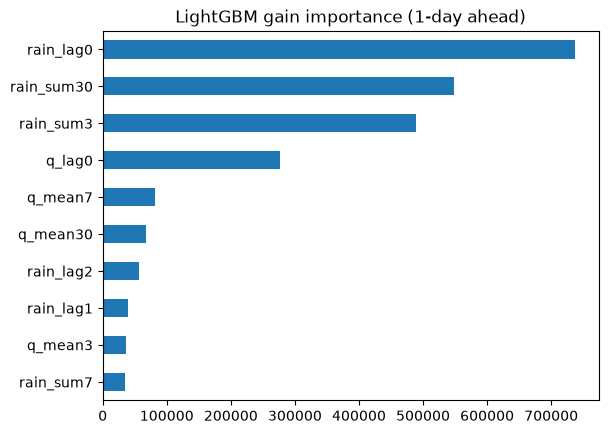

h=3 all      : NSE 0.457


h=3 no 90-day: NSE 0.455


catchment 0: local NSE 0.963 | global NSE 0.969


catchment 1: local NSE 0.963 | global NSE 0.969


catchment 2: local NSE 0.960 | global NSE 0.963


In [11]:
# Solution 1
no_rain = [c for c in X.columns if not c.startswith("rain")]
m_nr = lgb.LGBMRegressor(n_estimators=600, learning_rate=0.03, verbose=-1, random_state=0).fit(X_tr[no_rain], y_tr)
print(f"without rainfall features: NSE {nse(y_te.values, m_nr.predict(X_te[no_rain])):.3f} vs {nse(y_te.values, preds['LightGBM'].values):.3f}")
# Solution 2
imp = pd.Series(models["LightGBM"].booster_.feature_importance("gain"), index=X.columns).sort_values()
imp.tail(10).plot.barh(title="LightGBM gain importance (1-day ahead)"); plt.show()
# Solution 3
X3, y3 = make_features(df, horizon=3); s3 = X3.index < "2023-01-01"
for name, cols in [("all", X3.columns), ("no 90-day", [c for c in X3.columns if "90" not in c])]:
    m3 = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, verbose=-1, random_state=0).fit(X3[s3][cols], y3[s3])
    print(f"h=3 {name:<9}: NSE {nse(y3[~s3].values, m3.predict(X3[~s3][cols])):.3f}")
# Solution 4
def catchment(k, seed):
    r = np.random.default_rng(seed); st, qq = 0.0, np.zeros(n)
    for i in range(n):
        st = k * st + 0.6 * rain[i]; qq[i] = 5 + (1 - k) * 2.5 * st + 0.5 * (rain[i - 1] if i else 0)
    return pd.DataFrame({"rain": rain, "discharge": qq * r.lognormal(0, 0.08, n)}, index=dates)
frames = []
for cid, k in enumerate([0.95, 0.97, 0.99]):
    Xc, yc = make_features(catchment(k, cid)); frames.append(Xc.assign(cid=cid, target=yc))
allc = pd.concat(frames); s_all = allc.index < "2023-01-01"
glob = lgb.LGBMRegressor(n_estimators=600, learning_rate=0.03, verbose=-1, random_state=0).fit(allc[s_all].drop(columns="target"), allc[s_all].target)
for cid in range(3):
    d_ = allc[allc.cid == cid]; tr_m, te_m = d_.index < "2023-01-01", d_.index >= "2023-01-01"
    loc = lgb.LGBMRegressor(n_estimators=600, learning_rate=0.03, verbose=-1, random_state=0).fit(d_[tr_m].drop(columns="target"), d_[tr_m].target)
    print(f"catchment {cid}: local NSE {nse(d_[te_m].target.values, loc.predict(d_[te_m].drop(columns='target'))):.3f} | global NSE {nse(d_[te_m].target.values, glob.predict(d_[te_m].drop(columns='target'))):.3f}")

## **Key References**
- Makridakis, S., Spiliotis, E., & Assimakopoulos, V. (2022). M5 accuracy competition: Results, findings, and conclusions. *International Journal of Forecasting*, 38(4), 1346-1364.
- Taieb, S. B., Bontempi, G., Atiya, A. F., & Sorjamaa, A. (2012). A review and comparison of strategies for multi-step ahead time series forecasting. *Expert Systems with Applications*, 39(8), 7067-7083.
- Nash, J. E., & Sutcliffe, J. V. (1970). River flow forecasting through conceptual models part I. *Journal of Hydrology*, 10(3), 282-290.
- Montero-Manso, P., & Hyndman, R. J. (2021). Principles and algorithms for forecasting groups of time series: Locality and globality. *International Journal of Forecasting*, 37(4), 1632-1653.
- Kratzert, F. et al. (2019). Towards learning universal, regional, and local hydrological behaviors via machine learning applied to large-sample datasets. *Hydrology and Earth System Sciences*, 23, 5089-5110.